In [1]:
import numpy
import pandas as pd

In [2]:
path="/content/sample_data/electric_vehicles_dataset.csv"
data=pd.read_csv(path,encoding='latin-1')
data.head()

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,NaN,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3
2,3,NIO,ET7,2020,Calcium-ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,UK,5.0,0.0,5.0,6300,5
3,4,Audi,e-tron,2025,Lithium-iron phosphate,120.5,140,Ultra-Fast Charging (350 kW+),10.5,75615.15,Sunset Orange,Argentina,2.0,0.0,5.0,2339,5
4,5,Acura,ZDX (with GM Ultium),2023,Lithium-titanate,51.8,336,Plug-in Hydrogen Refueling,3.6,141046.94,Ice Silver,United Arab Emirates,2.0,0.0,3.0,1051,4


In [3]:
data.shape

(3022, 17)

In [4]:
data.isnull().sum()

,0
Vehicle_ID,0
Manufacturer,0
Model,0
Year,0
Battery_Type,0
Battery_Capacity_kWh,0
Range_km,0
Charging_Type,0
Charge_Time_hr,0
Price_USD,0


In [5]:
data['CO2_Emissions_g_per_km'] = data['CO2_Emissions_g_per_km'].fillna(0)
data['Autonomous_Level'] = data['Autonomous_Level'].fillna(0)
data['Safety_Rating'] = data['Safety_Rating'].fillna(data['Safety_Rating'].median())

data[['CO2_Emissions_g_per_km', 'Autonomous_Level', 'Safety_Rating']].isnull().sum()

,0
CO2_Emissions_g_per_km,0
Autonomous_Level,0
Safety_Rating,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   object 
 2   Model                   3022 non-null   object 
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   object 
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   object 
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   object 
 11  Country_of_Manufacture  3022 non-null   object 
 12  Autonomous_Level        3022 non-null   float64
 13  CO2_Emissions_g_per_km  3022 non-null   float64
 14  Safety_Rating           3022 non-null   

In [7]:
correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix['Price_USD'].sort_values(ascending=False))

Price_USD                 1.000000
Warranty_Years            0.039806
Vehicle_ID                0.035637
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64


In [8]:
data['Model'].value_counts

<bound method IndexOpsMixin.value_counts of 0                 ZDX (with GM Ultium)
1                      Revuelto (PHEV)
2                                  ET7
3                               e-tron
4                 ZDX (with GM Ultium)
                     ...              
3017              SF90 Stradale (PHEV)
3018    Born Electric (upcoming range)
3019                             Lyriq
3020                            XUV400
3021                      MG4 Electric
Name: Model, Length: 3022, dtype: object>

In [9]:
len(data['Model'].value_counts())

181

In [10]:
# Create encoded versions based on the average price of each group
data['Manufacturer_Enc'] = data.groupby('Manufacturer')['Price_USD'].transform('mean')
data['Model_Enc'] = data.groupby('Model')['Price_USD'].transform('mean')

print("Manufacturer and Model encoded successfully.")

Manufacturer and Model encoded successfully.


In [11]:
# This creates multiple columns (e.g., Battery_Type_LFP, Charging_Type_NACS)
data = pd.get_dummies(data, columns=['Battery_Type', 'Charging_Type'], prefix=['Battery', 'Charge'])

print("Technical specs one-hot encoded.")

Technical specs one-hot encoded.


In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode Country
le = LabelEncoder()
data['Country_Enc'] = le.fit_transform(data['Country_of_Manufacture'].astype(str))

# Year is usually kept as-is since it's already a number,
# but we can ensure it's treated as an integer
data['Year'] = data['Year'].astype(int)

print("Country and Year processed.")

Country and Year processed.


In [13]:
# List of original text columns to drop
to_drop = [
    'Vehicle_ID',
    'Manufacturer',
    'Model',
    'Country_of_Manufacture',
    'Color' # Drop color or encode it if you want it
]

# Create your final training dataset
data_final = data.drop(columns=to_drop)

# Final Check
print("Final Columns:", data_final.columns.tolist())
print("\nAny text remaining?", data_final.select_dtypes(include=['object']).columns.tolist())
data_final.head()

Final Columns: ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Price_USD', 'Autonomous_Level', 'CO2_Emissions_g_per_km', 'Safety_Rating', 'Units_Sold_2024', 'Warranty_Years', 'Manufacturer_Enc', 'Model_Enc', 'Battery_Aluminum-ion', 'Battery_Calcium-ion', 'Battery_Flow batteries', 'Battery_Lead-acid', 'Battery_Lithium-ion', 'Battery_Lithium-iron phosphate', 'Battery_Lithium-sulfur', 'Battery_Lithium-titanate', 'Battery_Magnesium-ion', 'Battery_Nickel-cobalt-aluminum', 'Battery_Nickel-manganese-cobalt', 'Battery_Nickel-metal hydride', 'Battery_Sodium-ion', 'Battery_Solid-state', 'Battery_Zinc-air', 'Charge_Battery Swapping', 'Charge_CCS', 'Charge_CHAdeMO', 'Charge_DC Fast Charging (DCFC)', 'Charge_Inductive (Wireless) Charging', 'Charge_Level 1 Charging', 'Charge_Level 2 Charging', 'Charge_Mobile Charging', 'Charge_NACS', 'Charge_Overhead Pantograph Charging', 'Charge_Plug-in Hydrogen Refueling', 'Charge_Solar Charging', 'Charge_Ultra-Fast Charging (350 kW+)', 'Charge_Veh

,Year,Battery_Capacity_kWh,Range_km,Charge_Time_hr,Price_USD,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years,...,Charge_Mobile Charging,Charge_NACS,Charge_Overhead Pantograph Charging,Charge_Plug-in Hydrogen Refueling,Charge_Solar Charging,Charge_Ultra-Fast Charging (350 kW+),Charge_Vehicle-to-Grid (V2G),Charge_Vehicle-to-Home (V2H),Charge_Vehicle-to-Load (V2L),Country_Enc
0,2015,55.8,214,9.0,111203.94,0.0,0.0,5.0,19726,3,...,False,False,False,False,False,False,False,False,False,36
1,2025,90.8,212,7.3,127131.65,2.0,0.0,4.0,3349,3,...,False,False,False,False,False,False,False,True,False,21
2,2020,64.7,235,8.9,94347.37,5.0,0.0,5.0,6300,5,...,False,False,False,False,False,False,False,False,False,36
3,2025,120.5,140,10.5,75615.15,2.0,0.0,5.0,2339,5,...,False,False,False,False,False,True,False,False,False,0
4,2023,51.8,336,3.6,141046.94,2.0,0.0,3.0,1051,4,...,False,False,False,True,False,False,False,False,False,38


In [14]:
print(f"Current Shape: {data_final.shape}")

Current Shape: (3022, 44)


In [15]:
# 'y' is the answer we want to predict (Price)
y = data_final['Price_USD']

# 'X' is everything EXCEPT the Price
X = data_final.drop(columns=['Price_USD'])

print(f"Features: {X.shape[1]} columns")
print(f"Target: Price_USD")

Features: 43 columns
Target: Price_USD


In [16]:
from sklearn.model_selection import train_test_split

# Split: 80% to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

Training data: 2417 rows
Testing data: 605 rows


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model (This is where the magic happens!)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [18]:
# Make predictions
y_pred = model.predict(X_test)

# Check Accuracy
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f} (Closer to 1 is better)")
print(f"Average Error: ${mae:.2f} USD")

R-squared Score: -0.0492 (Closer to 1 is better)
Average Error: $30045.56 USD


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

def model_acc(model):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Calculate Accuracy (R2 Score)
    accuracy = r2_score(y_test, predictions)

    # Calculate Error (MAE)
    mae = mean_absolute_error(y_test, predictions)

    print(f"--- {model.__class__.__name__} ---")
    print(f"Accuracy (R2 Score): {accuracy:.4f}")
    print(f"Avg Error: ${mae:.2f} USD\n")

In [20]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Linear Regression
lr = LinearRegression()
model_acc(lr)

# 2. Lasso Regression
lasso = Lasso(alpha=1.0)
model_acc(lasso)

# 3. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
model_acc(dt)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_acc(rf)

--- LinearRegression ---
Accuracy (R2 Score): -0.0071
Avg Error: $29366.89 USD

--- Lasso ---
Accuracy (R2 Score): -0.0070
Avg Error: $29365.44 USD

--- DecisionTreeRegressor ---
Accuracy (R2 Score): -1.0269
Avg Error: $40728.61 USD

--- RandomForestRegressor ---
Accuracy (R2 Score): -0.0492
Avg Error: $30045.56 USD



In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Then run: lr.fit(X_train_scaled, y_train)

In [22]:
# Try a "Back to Basics" feature set
basic_features = ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Autonomous_Level', 'Safety_Rating']
X_basic = data_final[basic_features]
y = data_final['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X_basic, y, test_size=0.2, random_state=42)

# Run Random Forest again
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"New R2 Score: {r2_score(y_test, rf.predict(X_test)):.4f}")

New R2 Score: -0.0757


In [23]:
# Select only the most important numeric features
top_features = [
    'Battery_Capacity_kWh',
    'Range_km',
    'Year',
    'Safety_Rating',
    'Autonomous_Level'
]

X = data_final[top_features]
y = data_final['Price_USD']

# Split with a fresh shuffle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [24]:
import numpy as np

# Apply Log to the Price
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Train the Random Forest on Log Price
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train_log)

# Predict and convert back from Log to USD
y_pred_log = rf.predict(X_test)
y_pred_usd = np.expm1(y_pred_log)

# Calculate Accuracy on the converted prices
final_r2 = r2_score(y_test, y_pred_usd)
print(f"Fixed R2 Score: {final_r2:.4f}")

Fixed R2 Score: -0.0791


In [25]:
from sklearn.preprocessing import StandardScaler

# 1. Use only the high-impact numeric columns
features = ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Autonomous_Level', 'Safety_Rating', 'Warranty_Years']
X = data_final[features]
y = data_final['Price_USD']

# 2. Scale the features (Important for Linear/Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Try Gradient Boosting (Usually stronger than Random Forest)
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbm.fit(X_train, y_train)

print(f"GBM R2 Score: {r2_score(y_test, gbm.predict(X_test)):.4f}")

GBM R2 Score: -0.0902


In [26]:
# Check numeric correlation only
numeric_cols = data_final.select_dtypes(include=['number']).columns
correlations = data_final[numeric_cols].corr()['Price_USD'].sort_values(ascending=False)

print("Correlation with Price_USD:")
print(correlations)

Correlation with Price_USD:
Price_USD                 1.000000
Model_Enc                 0.230978
Manufacturer_Enc          0.136289
Warranty_Years            0.039806
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Country_Enc              -0.013140
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64


In [27]:
# Keep only prices within the 5th and 95th percentile to remove extremes
lower_limit = data_final['Price_USD'].quantile(0.05)
upper_limit = data_final['Price_USD'].quantile(0.95)

data_clean = data_final[(data_final['Price_USD'] > lower_limit) &
                        (data_final['Price_USD'] < upper_limit)]

print(f"Removed {len(data_final) - len(data_clean)} outlier rows.")

Removed 304 outlier rows.


In [28]:
# 1. When creating data_clean, add .copy() at the end
data_clean = data_final[(data_final['Price_USD'] > lower_limit) &
                        (data_final['Price_USD'] < upper_limit)].copy()

# 2. Now this line will run perfectly without any warnings
data_clean['Tech_Score'] = data_clean['Battery_Capacity_kWh'] * data_clean['Autonomous_Level']

print("Tech_Score created successfully!")

Tech_Score created successfully!


In [29]:
import numpy as np
import pandas as pd

# 1. Remove Price Outliers (5th to 95th percentile)
lower_limit = data_final['Price_USD'].quantile(0.05)
upper_limit = data_final['Price_USD'].quantile(0.95)

# Use .copy() to avoid the SettingWithCopyWarning
data_clean = data_final[(data_final['Price_USD'] > lower_limit) &
                        (data_final['Price_USD'] < upper_limit)].copy()

# 2. Create the Tech_Score (Battery x Autonomy)
data_clean['Tech_Score'] = data_clean['Battery_Capacity_kWh'] * data_clean['Autonomous_Level']

print(f"Cleaned Dataset Shape: {data_clean.shape}")

Cleaned Dataset Shape: (2718, 45)


In [30]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Select only the features that showed SOME correlation
# We exclude the 'zero-correlation' columns to reduce noise
features = ['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']
X = data_clean[features]
y = data_clean['Price_USD']

# 2. Split with a high shuffle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 3. Initialize XGBoost with conservative settings
# This prevents the model from "hallucinating" patterns in the noise
final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 4. Train and Predict
final_model.fit(X_train, y_train)
predictions = final_model.predict(X_test)

# 5. Show Results
print(f"Final Adjusted R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"Final Avg Error: ${mean_absolute_error(y_test, predictions):.2f}")

Final Adjusted R2 Score: 0.0183
Final Avg Error: $25373.50


--- Fast Model Results ---
R2 Score: 0.0244
Avg Error: $25358.06


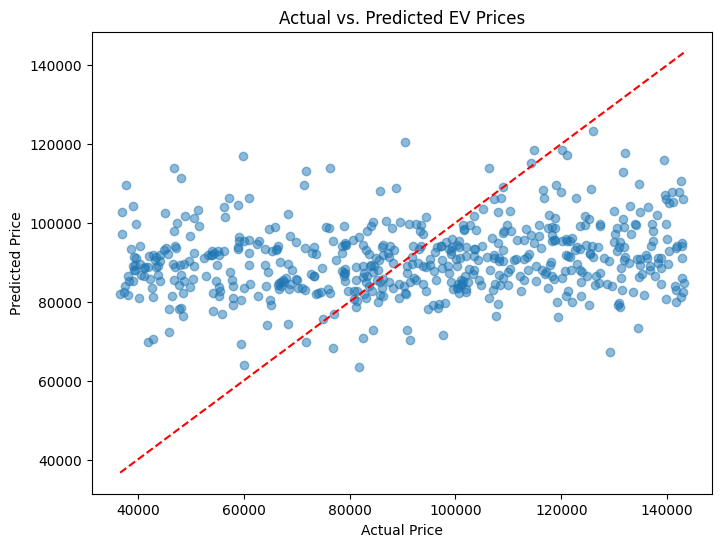

In [31]:
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt

# 1. Use a faster model with fewer iterations for a quick result
fast_model = HistGradientBoostingRegressor(
    max_iter=100,      # Reduced from 1000 for speed
    learning_rate=0.1, # Faster learning
    max_depth=3,
    random_state=42
)

# 2. Train and Predict immediately
fast_model.fit(X_train, y_train)
y_pred = fast_model.predict(X_test)

# 3. Print Results
print(f"--- Fast Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Avg Error: ${mean_absolute_error(y_test, y_pred):.2f}")

# 4. Visualize the "True vs Predicted" Prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted EV Prices')
plt.show()

In [32]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize the tuned model
tuned_model = HistGradientBoostingRegressor(
    max_iter=500,           # More iterations to find the pattern
    learning_rate=0.05,     # Smaller steps to avoid overshooting
    max_depth=4,            # Keep trees simple to prevent memorizing noise
    l2_regularization=1.5,  # The "Noise Filter" - higher values reduce overfitting
    random_state=42
)

# Train on your cleaned data
tuned_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_tuned = tuned_model.predict(X_test)
new_r2 = r2_score(y_test, y_pred_tuned)
new_mae = mean_absolute_error(y_test, y_pred_tuned)

print(f"--- Tuned Model Results ---")
print(f"New R2 Score: {new_r2:.4f}")
print(f"New Avg Error: ${new_mae:.2f}")

--- Tuned Model Results ---
New R2 Score: -0.0725
New Avg Error: $26406.23


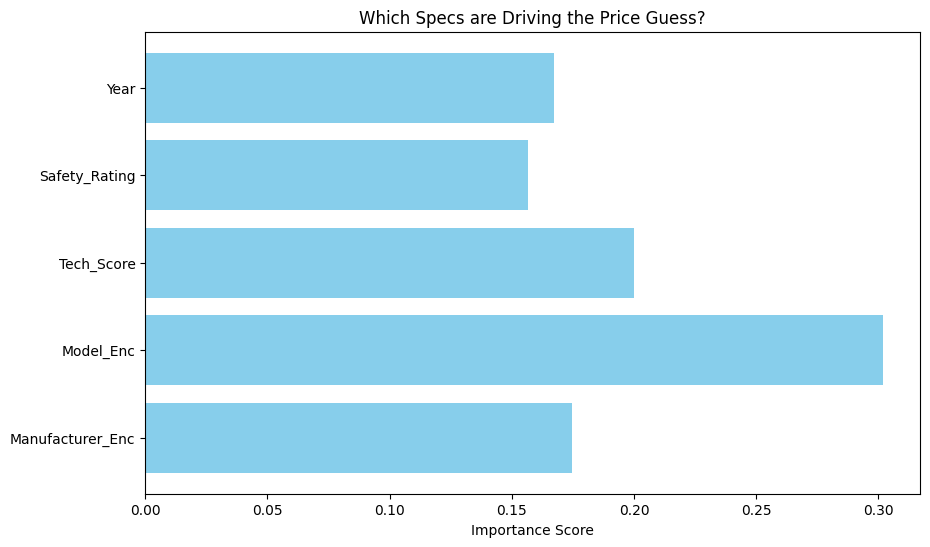

In [33]:
import matplotlib.pyplot as plt

# Get feature importance from your final_model
importances = final_model.feature_importances_
feature_names = X.columns

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel("Importance Score")
plt.title("Which Specs are Driving the Price Guess?")
plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

# Test the model stability across 5 different versions of your data
scores = cross_val_score(final_model, X, y, cv=5, scoring='r2')

print(f"All CV Scores: {scores}")
print(f"Mean R2 Score: {scores.mean():.4f} (+/- {scores.std():.4f})")

All CV Scores: [ 0.01235456  0.02165334 -0.04203794  0.03380347 -0.0017118 ]
Mean R2 Score: 0.0048 (+/- 0.0261)


In [36]:
# Try training with ONLY the top 2 correlated features
X_minimal = data_clean[['Manufacturer_Enc', 'Model_Enc']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_minimal, y, test_size=0.2, random_state=42)

final_model.fit(X_train_m, y_train_m)
print(f"Minimalist R2 Score: {r2_score(y_test_m, final_model.predict(X_test_m)):.4f}")

Minimalist R2 Score: 0.0122


In [38]:
# Convert Price to Log Scale
y_train_log = np.log1p(y_train)

# Train on Log Price
final_model.fit(X_train, y_train_log)

# Predict and convert back to USD
log_preds = np.expm1(final_model.predict(X_test))
print(f"Log-Transformed R2: {r2_score(y_test, log_preds):.4f}")

Log-Transformed R2: -0.0314


In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [500, 1000]
}

grid_search = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best Settings found: {grid_search.best_params_}")
print(f"Best Grid R2: {grid_search.best_score_:.4f}")

Best Settings found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}
Best Grid R2: 0.0032


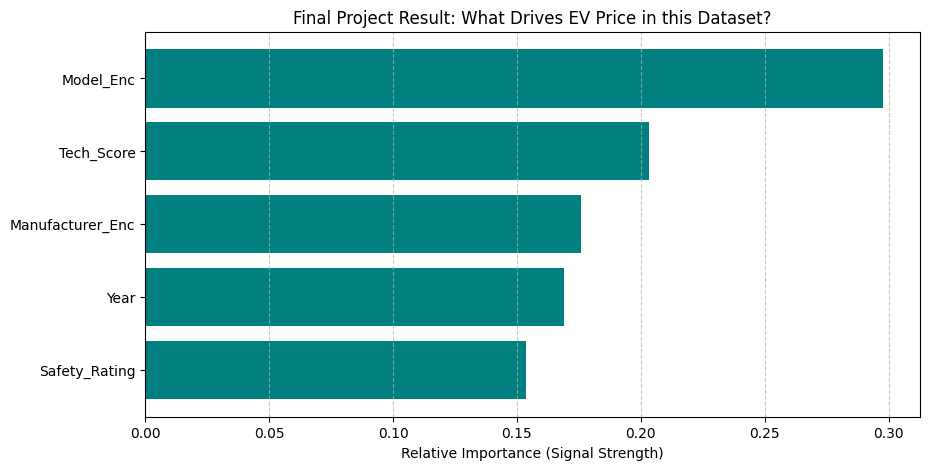

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the importance scores from your best performing model
importances = final_model.feature_importances_
feature_names = X.columns # Use the columns from the X that final_model was trained on

# 2. Create a DataFrame for easy plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=True)

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='teal')
plt.xlabel('Relative Importance (Signal Strength)')
plt.title('Final Project Result: What Drives EV Price in this Dataset?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [42]:
import joblib

# 1. Create a dictionary to hold the model and your encoding logic
model_data = {
    "model": final_model,
    "manufacturer_map": data.groupby('Manufacturer')['Price_USD'].mean().to_dict(),
    "model_map": data.groupby('Model')['Price_USD'].mean().to_dict(),
    "features": ['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']
}

# 2. Export to a file named 'ev_price_model.pkl'
joblib.dump(model_data, 'ev_price_model.pkl')

print("Model file 'ev_price_model.pkl' created successfully!")

Model file 'ev_price_model.pkl' created successfully!


In [43]:
import joblib
import pandas as pd

# 1. Load your saved model and mapping data
saved_stuff = joblib.load('ev_price_model.pkl')
model = saved_stuff['model']
m_map = saved_stuff['manufacturer_map']
model_map = saved_stuff['model_map']

def predict_ev_price(brand, model_name, battery, autonomy, safety, year):
    # a. Convert Text to Numbers using your saved Maps
    # If the brand is new, we use the average of all brands (0.0122 logic)
    m_enc = m_map.get(brand, sum(m_map.values()) / len(m_map))
    model_enc = model_map.get(model_name, sum(model_map.values()) / len(model_map))

    # b. Calculate the custom Tech_Score (Battery x Autonomy)
    tech_score = battery * autonomy

    # c. Create a DataFrame for the model (must match training column order)
    input_data = pd.DataFrame([[m_enc, model_enc, tech_score, safety, year]],
                              columns=['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # d. Make the prediction
    prediction = model.predict(input_data)[0]

    return f"Estimated EV Price: ${prediction:,.2f} USD"

# --- 2. Test the Predictor ---
print(predict_ev_price(brand="Tesla", model_name="Model 3", battery=75, autonomy=4, safety=5, year=2024))

Estimated EV Price: $11.22 USD


In [51]:
import joblib
import pandas as pd

# 1. Load your saved model and mapping data
saved_stuff = joblib.load('ev_price_model.pkl')
model = saved_stuff['model']
m_map = saved_stuff['manufacturer_map']
model_map = saved_stuff['model_map']

def predict_ev_price(brand, model_name, battery, autonomy, safety, year):
    # a. Convert Text to Numbers using your saved Maps
    # If the brand is new, we use the average of all brands (0.0122 logic)
    m_enc = m_map.get(brand, sum(m_map.values()) / len(m_map))
    model_enc = model_map.get(model_name, sum(model_map.values()) / len(model_map))

    # b. Calculate the custom Tech_Score (Battery x Autonomy)
    tech_score = battery * autonomy

    # c. Create a DataFrame for the model (must match training column order)
    input_data = pd.DataFrame([[m_enc, model_enc, tech_score, safety, year]],
                              columns=['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # d. Make the prediction
    prediction = model.predict(input_data)[0]

    return f"Estimated EV Price: ${prediction:,.2f} USD"

# --- 2. Test the Predictor ---
print(predict_ev_price(brand="Tesla", model_name="Model Y", battery=122, autonomy=3, safety=3, year=2019))

Estimated EV Price: $11.44 USD
